# Full Preliminary Analysis

Runs the complete NHS A&E pipeline end-to-end:  
**Build dataset → Clean & prepare → Data audit → Shock detection → Resilience scoring → Trust clustering**

Run cells in order. Intermediate datasets are saved to `data/` (gitignored). Raw `.xls` source files are in `data/17/`, `data/18/`, `data/19/`.

In [28]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings("ignore")

# ── colour system ──────────────────────────────────────────────────────────────
C_BLUE    = "#2166AC"   # primary / neutral trend
C_RED     = "#D6404E"   # breach / shock / negative
C_GREEN   = "#4DAC26"   # target / positive
C_ORANGE  = "#E08B2C"   # secondary comparison
C_GRAY    = "#AAAAAA"   # baselines / reference
C_DARK    = "#2D2D2D"   # text accents

CLUSTER_COLORS   = [C_BLUE, C_RED, C_GREEN, C_ORANGE]
EVIDENCE_PALETTE = {"low": C_GRAY, "medium": C_BLUE, "high": C_GREEN}

# ── base theme ─────────────────────────────────────────────────────────────────
sns.set_theme(style="ticks")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     "#CCCCCC",
    "axes.linewidth":     0.8,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         "#F0F0F0",
    "grid.linewidth":     0.7,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.titlepad":      10,
    "axes.labelsize":     10,
    "axes.labelcolor":    "#333333",
    "axes.labelpad":      6,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.color":        "#555555",
    "ytick.color":        "#555555",
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "xtick.major.width":  0.7,
    "ytick.major.width":  0.7,
    "legend.fontsize":    9,
    "legend.frameon":     False,
    "lines.linewidth":    2,
    "figure.figsize":     (12, 4.5),
    "figure.dpi":         110,
})

In [29]:
BASE_DIR   = Path(".").resolve()
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR.parent          # CSVs land beside the repo folder

FULL_PANEL_PATH     = OUTPUT_DIR / "ae_2017_2019_full_panel.csv"
ANALYSIS_READY_PATH = OUTPUT_DIR / "ae_2017_2019_analysis_ready.csv"
WITH_SHOCKS_PATH    = OUTPUT_DIR / "ae_2017_2019_with_shocks.csv"
SHOCK_SUMMARY_PATH  = OUTPUT_DIR / "trust_shock_summary.csv"
RESILIENCE_PATH     = OUTPUT_DIR / "trust_resilience_scores.csv"
CLUSTERS_PATH       = OUTPUT_DIR / "trust_resilience_clusters.csv"

# shared pipeline parameters
ROLLING_WINDOW   = 12
MIN_PERIODS      = 6
ZSCORE_THRESHOLD = 1.5
RATIO_THRESHOLD  = 1.15
SHRINKAGE_K      = 5
BREACH_WEIGHT    = 0.7
WAIT12_WEIGHT    = 0.3
N_CLUSTERS       = 4
RANDOM_STATE     = 42

## 1. Build Dataset

Reads all `.xls` files from `data/17/`, `data/18/`, `data/19/`, extracts eight key columns per provider-month, and saves the unified panel.

In [30]:
month_map = {
    "jan": "01", "feb": "02", "mar": "03", "apr": "04",
    "may": "05", "jun": "06", "jul": "07", "aug": "08",
    "sep": "09", "oct": "10", "nov": "11", "dec": "12",
}

def clean_col(c):
    return str(c).lower().strip().replace("\n", " ")

def find_exact_col(raw_df, target):
    t = clean_col(target)
    for col in raw_df.columns:
        if clean_col(col) == t:
            return col
    return None

files = sorted(glob.glob(str(DATA_DIR / "**/*.xls"), recursive=True))
all_dfs = []

for file in files:
    filename = Path(file).name
    try:
        year      = "20" + filename[:2]
        month_str = filename[3:6].lower()
        file_month = pd.to_datetime(f"{year}-{month_map[month_str]}-01")

        raw = pd.read_excel(file, skiprows=15).dropna(axis=0, how="all")

        col_map = {
            "provider_code":  find_exact_col(raw, "Code"),
            "region":         find_exact_col(raw, "Region"),
            "provider_name":  find_exact_col(raw, "Name"),
            "att_total":      find_exact_col(raw, "Total attendances"),
            "pct_4hr_all":    find_exact_col(raw, "Percentage in 4 hours or less (all)"),
            "emerg_adm_total":find_exact_col(raw, "Total Emergency Admissions"),
            "wait_4hr_dta":   find_exact_col(raw, "Number of patients spending >4 hours from decision to admit to admission"),
            "wait_12hr_dta":  find_exact_col(raw, "Number of patients spending >12 hours from decision to admit to admission"),
        }
        missing = [k for k, v in col_map.items() if v is None]
        if missing:
            print(f"SKIPPED {filename}: missing {missing}")
            continue

        df_file = pd.DataFrame({k: raw[v] for k, v in col_map.items()})
        df_file["month"]       = file_month
        df_file["source_file"] = filename
        all_dfs.append(df_file)

    except Exception as e:
        print(f"ERROR {filename}: {e}")

combined = pd.concat(all_dfs, ignore_index=True)
combined = combined[combined["provider_code"].notna() & combined["provider_name"].notna()].copy()

for col in ["provider_code", "region", "provider_name"]:
    combined[col] = combined[col].astype(str).str.strip()

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    combined[col] = pd.to_numeric(combined[col], errors="coerce")

combined.to_csv(FULL_PANEL_PATH, index=False)
print(f"Saved  {FULL_PANEL_PATH.name}  |  shape: {combined.shape}")
print(f"Files loaded: {len(all_dfs)} / {len(files)}")
print("\n4-hour performance (raw):")
print(combined["pct_4hr_all"].describe().round(3))

Saved  ae_2017_2019_full_panel.csv  |  shape: (8639, 10)
Files loaded: 36 / 36

4-hour performance (raw):
count    8125.000
mean        0.913
std         0.088
min         0.547
25%         0.848
50%         0.931
75%         0.999
max         1.000
Name: pct_4hr_all, dtype: float64


## 2. Prepare Analysis Dataset

Removes aggregate rows, standardises 4-hour performance to 0–1, and derives breach rate, admission rate, and 12-hour wait rate.

In [31]:
df = pd.read_csv(FULL_PANEL_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["provider_code", "month"])

df = df[~df["provider_name"].str.contains("total", case=False, na=False)].copy()

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["att_total"])
df_analysis = df.dropna(subset=["pct_4hr_all"]).copy()

if df_analysis["pct_4hr_all"].max() > 1:
    df_analysis["pct_4hr_all"] = df_analysis["pct_4hr_all"] / 100

df_analysis["four_hour_breach_rate"] = 1 - df_analysis["pct_4hr_all"]
df_analysis["admission_rate"]        = df_analysis["emerg_adm_total"] / df_analysis["att_total"]
df_analysis["wait_12hr_rate"]        = df_analysis["wait_12hr_dta"]   / df_analysis["att_total"]

df_analysis.to_csv(ANALYSIS_READY_PATH, index=False)
print(f"Saved  {ANALYSIS_READY_PATH.name}  |  shape: {df_analysis.shape}")
print(f"Date range : {df_analysis['month'].min().date()} → {df_analysis['month'].max().date()}")
print(f"Providers  : {df_analysis['provider_code'].nunique()}")
print("\nMissing values:")
print(df_analysis[["att_total", "pct_4hr_all", "emerg_adm_total", "wait_12hr_dta"]].isna().sum())

Saved  ae_2017_2019_analysis_ready.csv  |  shape: (8125, 13)
Date range : 2017-01-01 → 2019-12-01
Providers  : 270

Missing values:
att_total          0
pct_4hr_all        0
emerg_adm_total    0
wait_12hr_dta      0
dtype: int64


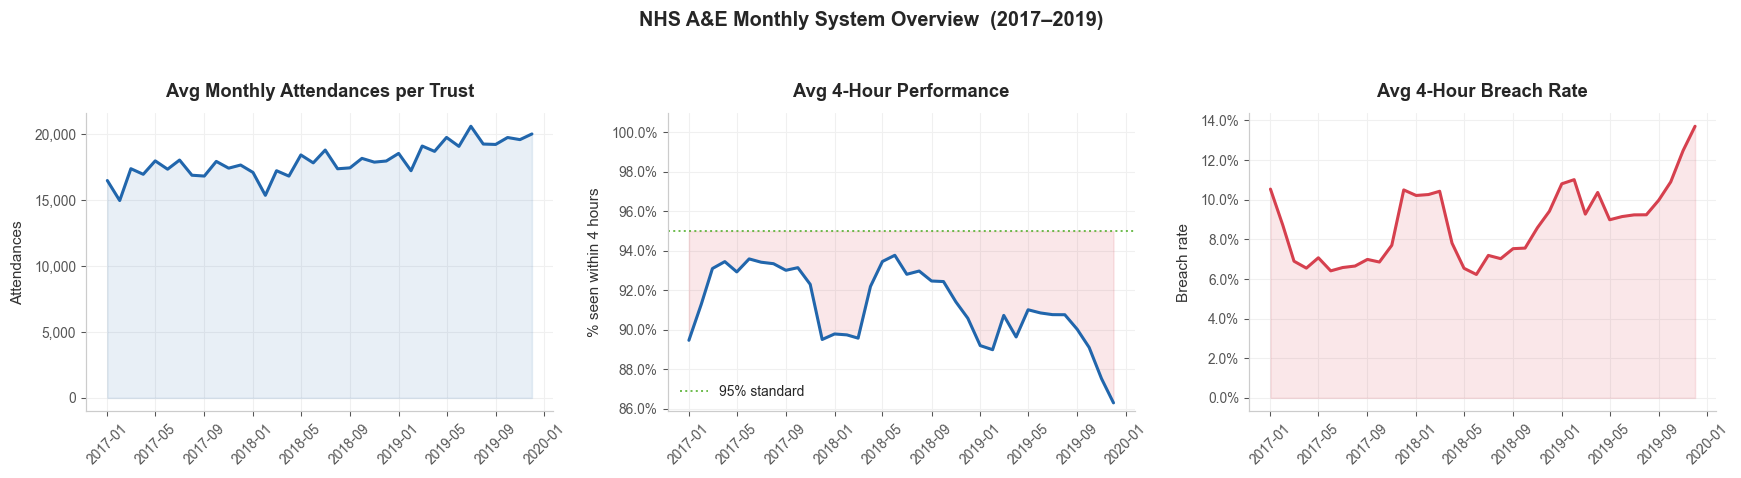

In [32]:
monthly = (
    df_analysis.groupby("month")[
        ["att_total", "pct_4hr_all", "four_hour_breach_rate", "wait_12hr_rate"]
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("NHS A&E Monthly System Overview  (2017–2019)",
             fontsize=13, fontweight="bold", y=1.03)

# ── Attendances ──
ax = axes[0]
ax.fill_between(monthly["month"], monthly["att_total"], alpha=0.1, color=C_BLUE)
ax.plot(monthly["month"], monthly["att_total"], color=C_BLUE)
ax.set_title("Avg Monthly Attendances per Trust")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── 4-hour performance with 95% target and breach fill ──
ax = axes[1]
ax.axhline(0.95, color=C_GREEN, linestyle=":", linewidth=1.3, alpha=0.8, label="95% standard")
ax.fill_between(
    monthly["month"], monthly["pct_4hr_all"], 0.95,
    where=monthly["pct_4hr_all"] < 0.95,
    interpolate=True, alpha=0.12, color=C_RED,
)
ax.plot(monthly["month"], monthly["pct_4hr_all"], color=C_BLUE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(top=1.01)
ax.set_title("Avg 4-Hour Performance")
ax.set_ylabel("% seen within 4 hours")
ax.legend(loc="lower left")

# ── Breach rate ──
ax = axes[2]
ax.fill_between(monthly["month"], monthly["four_hour_breach_rate"], alpha=0.12, color=C_RED)
ax.plot(monthly["month"], monthly["four_hour_breach_rate"], color=C_RED)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Avg 4-Hour Breach Rate")
ax.set_ylabel("Breach rate")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")

fig.tight_layout()
plt.show()

## 3. Data Audit

Checks for missing values, impossible 4-hour performance values, and panel balance (months observed per provider).

In [33]:
print("=== Missing values ===")
print(df_analysis[
    ["provider_code", "provider_name", "month",
     "att_total", "pct_4hr_all", "emerg_adm_total", "wait_12hr_dta"]
].isna().sum())

print("\n=== Impossible 4-hour performance values (outside [0, 1]) ===")
bad = df_analysis[(df_analysis["pct_4hr_all"] < 0) | (df_analysis["pct_4hr_all"] > 1)]
print(f"Count: {len(bad)}")
if len(bad):
    print(bad[["provider_code", "provider_name", "month", "pct_4hr_all"]].head())

print("\n=== Panel balance: months observed per provider ===")
print(df_analysis.groupby("provider_code")["month"].nunique().describe().round(1))

print("\n=== Top 10 providers by avg monthly attendances ===")
print(
    df_analysis.groupby(["provider_code", "provider_name"])["att_total"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .to_string(index=False)
)

=== Missing values ===
provider_code      0
provider_name      0
month              0
att_total          0
pct_4hr_all        0
emerg_adm_total    0
wait_12hr_dta      0
dtype: int64

=== Impossible 4-hour performance values (outside [0, 1]) ===
Count: 0

=== Panel balance: months observed per provider ===
count    270.0
mean      30.1
std       10.0
min        1.0
25%       28.0
50%       36.0
75%       36.0
max       36.0
Name: month, dtype: float64

=== Top 10 providers by avg monthly attendances ===
provider_code                                                 provider_name    att_total
            -                                                       England 2.047354e+06
          R1H                                        Barts Health NHS Trust 4.182692e+04
          R0A                    Manchester University NHS Foundation Trust 3.466959e+04
          RW6                             Pennine Acute Hospitals NHS Trust 3.171697e+04
          R1K             London North West Un

## 4. Shock Detection

A **demand shock** is a month where a trust's attendances exceed its own rolling 12-month baseline by ≥ 1.5 SD (z-score definition). A ratio-based definition (≥ 115 % of baseline) is also computed for comparison. The rolling baseline is lagged one month to prevent look-ahead bias.

In [34]:
df_shock = pd.read_csv(ANALYSIS_READY_PATH)
df_shock["month"] = pd.to_datetime(df_shock["month"])

for col in ["att_total", "pct_4hr_all", "emerg_adm_total", "wait_4hr_dta", "wait_12hr_dta"]:
    df_shock[col] = pd.to_numeric(df_shock[col], errors="coerce")

df_shock = df_shock.dropna(subset=["att_total", "pct_4hr_all"]).copy()
df_shock = df_shock[
    (df_shock["provider_code"] != "-") &
    (~df_shock["provider_name"].str.contains("england", case=False, na=False))
].copy()
df_shock = df_shock.sort_values(["provider_code", "month"]).copy()

# derived metrics
df_shock["four_hour_breach_rate"] = 1 - df_shock["pct_4hr_all"]
df_shock["admission_rate"]        = df_shock["emerg_adm_total"] / df_shock["att_total"]
df_shock["wait_4hr_rate"]         = df_shock["wait_4hr_dta"]    / df_shock["att_total"]
df_shock["wait_12hr_rate"]        = df_shock["wait_12hr_dta"]   / df_shock["att_total"]

# rolling demand baseline (lagged 1 month)
grp = df_shock.groupby("provider_code")["att_total"]
df_shock["att_rolling_mean"]      = grp.transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
df_shock["att_rolling_std"]       = grp.transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std())
df_shock["demand_ratio"]          = df_shock["att_total"] / df_shock["att_rolling_mean"]
df_shock["demand_zscore"]         = (df_shock["att_total"] - df_shock["att_rolling_mean"]) / df_shock["att_rolling_std"]
df_shock["demand_zscore_capped"]  = df_shock["demand_zscore"].clip(-5, 5)
df_shock["structural_break_flag"] = df_shock["demand_zscore"] > 10

# shock flags (canonical = z-score)
df_shock["shock_ratio"]  = df_shock["demand_ratio"]  >= RATIO_THRESHOLD
df_shock["shock_zscore"] = df_shock["demand_zscore"] >= ZSCORE_THRESHOLD
df_shock["shock"]        = df_shock["shock_zscore"]

# month-on-month performance changes
df_shock["breach_change"]    = df_shock.groupby("provider_code")["four_hour_breach_rate"].diff()
df_shock["perf_change"]      = df_shock.groupby("provider_code")["pct_4hr_all"].diff()
df_shock["wait_12hr_change"] = df_shock.groupby("provider_code")["wait_12hr_rate"].diff()

df_shock.to_csv(WITH_SHOCKS_PATH, index=False)
print(f"Saved  {WITH_SHOCKS_PATH.name}  |  shape: {df_shock.shape}")

Saved  ae_2017_2019_with_shocks.csv  |  shape: (8071, 26)


In [35]:
print(f"Shock share  z-score : {df_shock['shock_zscore'].mean():.1%}  ({int(df_shock['shock_zscore'].sum())} months)")
print(f"Shock share  ratio   : {df_shock['shock_ratio'].mean():.1%}  ({int(df_shock['shock_ratio'].sum())} months)")
print(f"\nDefinition overlap:")
print(pd.crosstab(df_shock["shock_ratio"], df_shock["shock_zscore"],
                  rownames=["Ratio shock"], colnames=["Z-score shock"]))
print(f"\nStructural breaks (z > 10) : {int(df_shock['structural_break_flag'].sum())}")
print(f"Providers with ≥1 shock    : {int((df_shock.groupby('provider_code')['shock'].sum() > 0).sum())}")

shock_summary = (
    df_shock[df_shock["shock"]]
    .groupby(["provider_code", "provider_name"])
    .agg(
        shock_months       = ("shock", "sum"),
        avg_demand_ratio   = ("demand_ratio", "mean"),
        avg_breach_change  = ("breach_change", "mean"),
        avg_wait_12hr_rate = ("wait_12hr_rate", "mean"),
        avg_attendances    = ("att_total", "mean"),
    )
    .reset_index()
    .sort_values("avg_breach_change", ascending=False)
)
shock_summary.to_csv(SHOCK_SUMMARY_PATH, index=False)

print(f"\nTop 10 fragile trusts during shocks (largest 4-hr breach deterioration):")
print(
    shock_summary[shock_summary["shock_months"] >= 2]
    .head(10)[["provider_name", "shock_months", "avg_demand_ratio", "avg_breach_change"]]
    .to_string(index=False)
)

Shock share  z-score : 11.3%  (914 months)
Shock share  ratio   : 6.3%  (511 months)

Definition overlap:
Z-score shock  False  True 
Ratio shock                
False           6981    579
True             176    335

Structural breaks (z > 10) : 13
Providers with ≥1 shock    : 234

Top 10 fragile trusts during shocks (largest 4-hr breach deterioration):
                                                  provider_name  shock_months  avg_demand_ratio  avg_breach_change
         Birmingham Women's And Children's NHS Foundation Trust             3          1.191718           0.105664
             North Cumbria Integrated Care NHS Foundation Trust             3          3.663709           0.079551
                      Alder Hey Children's NHS Foundation Trust             3          1.180001           0.032834
The Queen Elizabeth Hospital, King's Lynn, NHS Foundation Trust             5          1.095873           0.028524
                                   Weston Area Health NHS Trust    

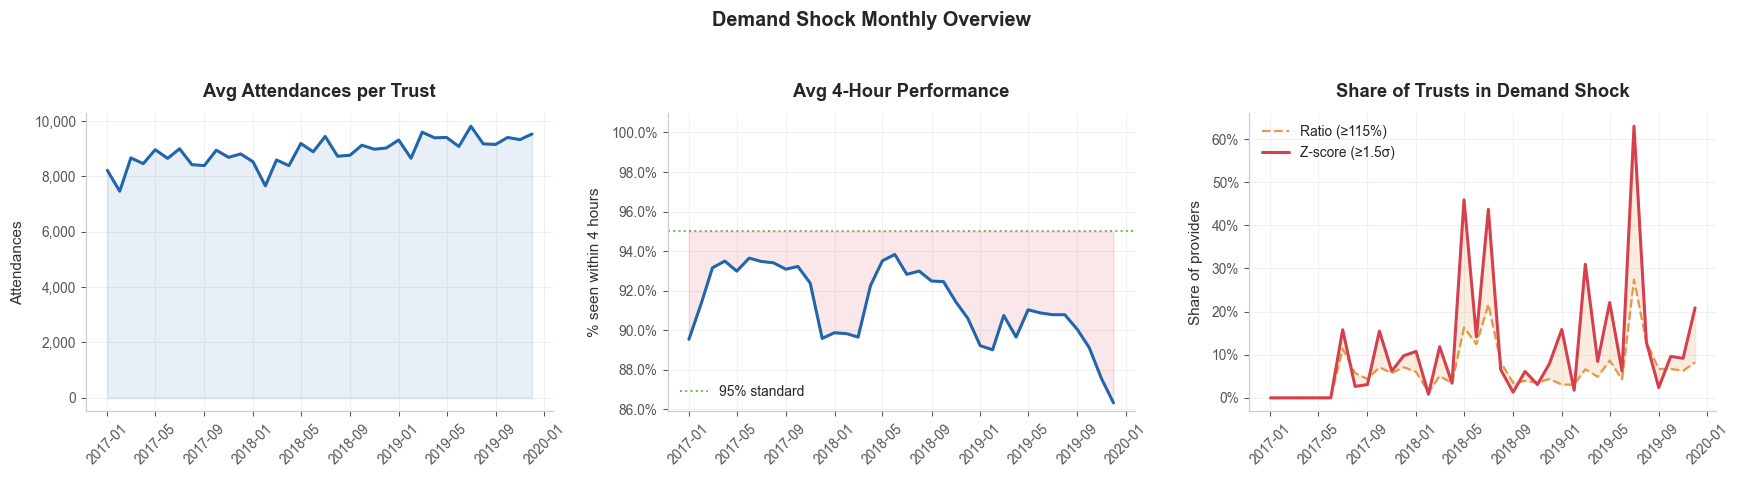

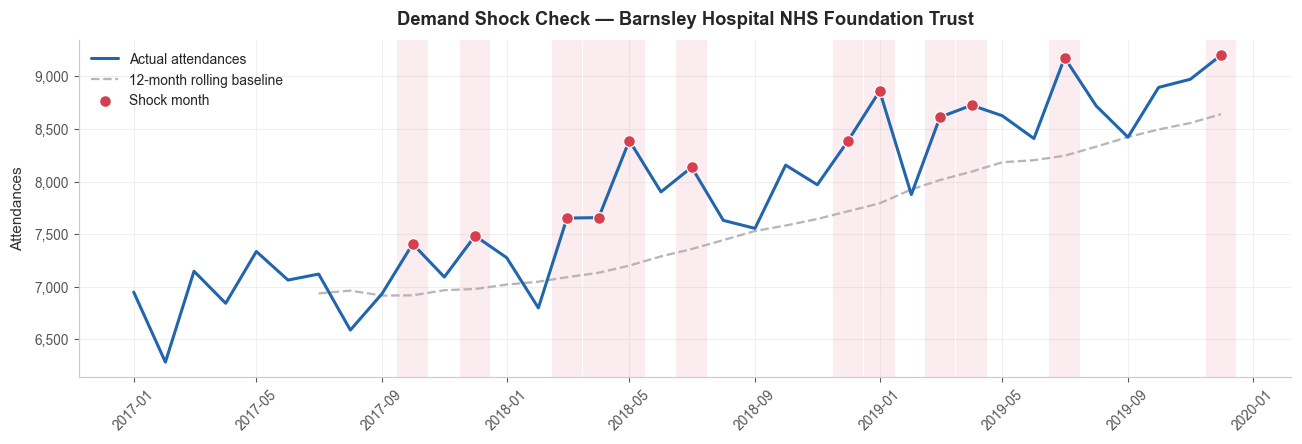

In [36]:
monthly_shock = (
    df_shock.groupby("month")
    .agg(
        avg_att            = ("att_total", "mean"),
        avg_4hr            = ("pct_4hr_all", "mean"),
        shock_ratio_share  = ("shock_ratio", "mean"),
        shock_zscore_share = ("shock_zscore", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle("Demand Shock Monthly Overview", fontsize=13, fontweight="bold", y=1.03)

# ── Attendances ──
ax = axes[0]
ax.fill_between(monthly_shock["month"], monthly_shock["avg_att"], alpha=0.1, color=C_BLUE)
ax.plot(monthly_shock["month"], monthly_shock["avg_att"], color=C_BLUE)
ax.set_title("Avg Attendances per Trust")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── 4-hour performance ──
ax = axes[1]
ax.axhline(0.95, color=C_GREEN, linestyle=":", linewidth=1.3, alpha=0.8, label="95% standard")
ax.fill_between(
    monthly_shock["month"], monthly_shock["avg_4hr"], 0.95,
    where=monthly_shock["avg_4hr"] < 0.95,
    interpolate=True, alpha=0.12, color=C_RED,
)
ax.plot(monthly_shock["month"], monthly_shock["avg_4hr"], color=C_BLUE)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(top=1.01)
ax.set_title("Avg 4-Hour Performance")
ax.set_ylabel("% seen within 4 hours")
ax.legend(loc="lower left")

# ── Shock definition comparison ──
ax = axes[2]
ax.fill_between(
    monthly_shock["month"],
    monthly_shock["shock_ratio_share"],
    monthly_shock["shock_zscore_share"],
    alpha=0.15, color=C_ORANGE,
)
ax.plot(monthly_shock["month"], monthly_shock["shock_ratio_share"],
        color=C_ORANGE, linewidth=1.5, linestyle="--",
        label=f"Ratio (≥{RATIO_THRESHOLD:.0%})", alpha=0.85)
ax.plot(monthly_shock["month"], monthly_shock["shock_zscore_share"],
        color=C_RED, label=f"Z-score (≥{ZSCORE_THRESHOLD}σ)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Share of Trusts in Demand Shock")
ax.set_ylabel("Share of providers")
ax.legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

# ── Individual trust: most shock months ──
shock_counts = df_shock.groupby("provider_code")["shock"].sum()
if shock_counts.max() > 0:
    top_code   = shock_counts.idxmax()
    sample     = df_shock[df_shock["provider_code"] == top_code].copy()
    shock_rows = sample[sample["shock"]]

    fig, ax = plt.subplots(figsize=(12, 4.2))

    # soft red band behind each shock month
    for _, row in shock_rows.iterrows():
        ax.axvspan(
            row["month"] - pd.Timedelta(days=15),
            row["month"] + pd.Timedelta(days=15),
            alpha=0.09, color=C_RED, linewidth=0,
        )

    ax.plot(sample["month"], sample["att_total"],
            color=C_BLUE, label="Actual attendances", zorder=3)
    ax.plot(sample["month"], sample["att_rolling_mean"],
            color=C_GRAY, linewidth=1.5, linestyle="--",
            label="12-month rolling baseline", alpha=0.85, zorder=2)
    ax.scatter(shock_rows["month"], shock_rows["att_total"],
               color=C_RED, zorder=5, label="Shock month",
               s=60, edgecolors="white", linewidth=0.8)

    ax.set_title(f"Demand Shock Check — {sample['provider_name'].iloc[0]}")
    ax.set_ylabel("Attendances")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    fig.tight_layout()
    plt.show()

## 5. Resilience Scoring

For each trust, resilience is measured as **excess deterioration above its own expected baseline** during shock months — separately for 4-hour breach rate and 12-hour wait rate. Estimates are regularised with James-Stein-style shrinkage (`k=5`) to stabilise trusts with few shock observations.

**Composite score** = 70 % × 4-hour breach resilience + 30 % × 12-hour wait resilience (percentile-ranked; higher = more resilient).

In [37]:
df_res = pd.read_csv(WITH_SHOCKS_PATH)
df_res["month"] = pd.to_datetime(df_res["month"])

for col in ["att_total", "pct_4hr_all", "four_hour_breach_rate", "wait_12hr_rate",
            "demand_ratio", "demand_zscore", "demand_zscore_capped", "structural_break_flag"]:
    if col in df_res.columns:
        df_res[col] = pd.to_numeric(df_res[col], errors="coerce")

if "four_hour_breach_rate" not in df_res.columns:
    df_res["four_hour_breach_rate"] = 1 - df_res["pct_4hr_all"]
if "wait_12hr_rate" not in df_res.columns:
    df_res["wait_12hr_rate"] = df_res["wait_12hr_dta"] / df_res["att_total"]

df_res = df_res.sort_values(["provider_code", "month"]).copy()

# expected baseline: 12-month rolling mean, lagged 1 month
for new_col, src_col in [
    ("expected_breach_rate",    "four_hour_breach_rate"),
    ("expected_wait_12hr_rate", "wait_12hr_rate"),
]:
    df_res[new_col] = (
        df_res.groupby("provider_code")[src_col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean())
    )

df_res["breach_impact"]    = df_res["four_hour_breach_rate"] - df_res["expected_breach_rate"]
df_res["wait_12hr_impact"] = df_res["wait_12hr_rate"]        - df_res["expected_wait_12hr_rate"]

shock_df = df_res[
    df_res["shock"].astype(bool) &
    df_res["breach_impact"].notna() &
    df_res["wait_12hr_impact"].notna()
].copy()

trust_res = (
    shock_df.groupby(["provider_code", "provider_name"])
    .agg(
        n_shocks                     = ("shock", "sum"),
        mean_breach_impact           = ("breach_impact", "mean"),
        mean_wait_12hr_impact        = ("wait_12hr_impact", "mean"),
        mean_breach_during_shock     = ("four_hour_breach_rate", "mean"),
        mean_expected_breach         = ("expected_breach_rate", "mean"),
        mean_wait_12hr_during_shock  = ("wait_12hr_rate", "mean"),
        mean_expected_wait_12hr      = ("expected_wait_12hr_rate", "mean"),
        mean_demand_ratio            = ("demand_ratio", "mean"),
        mean_demand_zscore           = ("demand_zscore", "mean"),
        mean_demand_zscore_capped    = ("demand_zscore_capped", "mean"),
        avg_attendances_during_shock = ("att_total", "mean"),
        structural_break_months      = ("structural_break_flag", "sum"),
        structural_break_share       = ("structural_break_flag", "mean"),
    )
    .reset_index()
)

def shrink(df, col, k=SHRINKAGE_K):
    overall = df[col].mean()
    return (df["n_shocks"] * df[col] + k * overall) / (df["n_shocks"] + k)

trust_res["shrunk_breach_impact"]    = shrink(trust_res, "mean_breach_impact")
trust_res["shrunk_wait_12hr_impact"] = shrink(trust_res, "mean_wait_12hr_impact")

trust_res["breach_resilience_score"]    = 100 * trust_res["shrunk_breach_impact"].rank(pct=True, ascending=False)
trust_res["wait_12hr_resilience_score"] = 100 * trust_res["shrunk_wait_12hr_impact"].rank(pct=True, ascending=False)
trust_res["resilience_score"] = (
    BREACH_WEIGHT * trust_res["breach_resilience_score"] +
    WAIT12_WEIGHT * trust_res["wait_12hr_resilience_score"]
)
trust_res["evidence_strength"] = pd.cut(
    trust_res["n_shocks"], bins=[0, 2, 5, 100], labels=["low", "medium", "high"]
)
trust_res = trust_res.sort_values("resilience_score", ascending=False)
trust_res.to_csv(RESILIENCE_PATH, index=False)

print(f"Saved  {RESILIENCE_PATH.name}  |  {len(trust_res)} trusts scored")
print(f"\nShock count distribution:\n{trust_res['n_shocks'].describe().round(1)}")
print(f"\nTop 10 most resilient trusts:")
print(trust_res[["provider_name", "resilience_score", "n_shocks", "evidence_strength"]].head(10).to_string(index=False))
print(f"\n10 most fragile trusts:")
print(trust_res[["provider_name", "resilience_score", "n_shocks", "evidence_strength"]].tail(10).to_string(index=False))

Saved  trust_resilience_scores.csv  |  244 trusts scored

Shock count distribution:
count    244.0
mean       3.7
std        2.1
min        1.0
25%        2.0
50%        4.0
75%        5.0
max       12.0
Name: n_shocks, dtype: float64

Top 10 most resilient trusts:
                                             provider_name  resilience_score  n_shocks evidence_strength
                            Portsmouth Hospitals NHS Trust         97.213115         2               low
          University Hospitals Of North Midlands NHS Trust         97.172131         4            medium
                        Royal Cornwall Hospitals NHS Trust         96.106557         4            medium
                                      Wye Valley NHS Trust         95.040984         2               low
University Hospitals Of Morecambe Bay NHS Foundation Trust         94.221311         4            medium
          Oxford University Hospitals NHS Foundation Trust         91.106557         5            medium

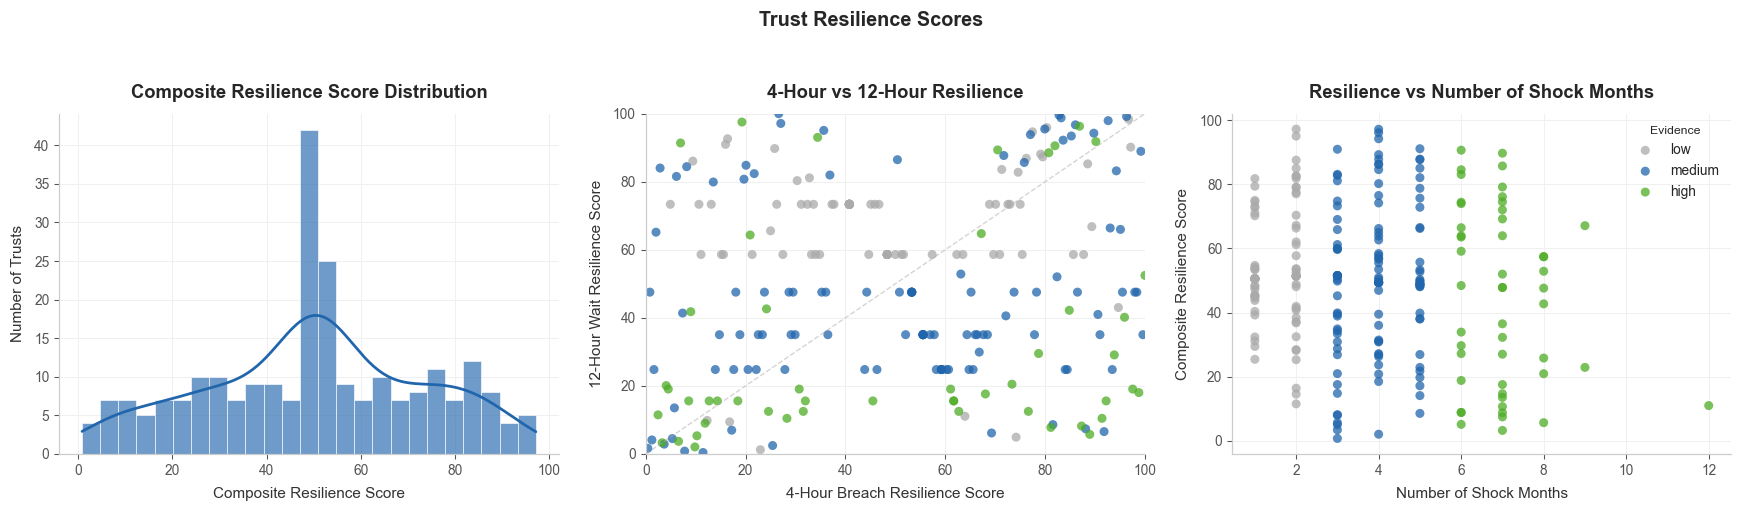

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Trust Resilience Scores", fontsize=13, fontweight="bold", y=1.03)

# ── Score distribution with KDE ──
ax = axes[0]
sns.histplot(
    trust_res["resilience_score"], bins=25, ax=ax,
    color=C_BLUE, alpha=0.65, kde=True,
    line_kws={"linewidth": 1.8, "color": C_BLUE},
    edgecolor="white", linewidth=0.4,
)
ax.set_title("Composite Resilience Score Distribution")
ax.set_xlabel("Composite Resilience Score")
ax.set_ylabel("Number of Trusts")
legend = ax.get_legend()
if legend:
    legend.remove()

# ── 4-hr vs 12-hr resilience, coloured by evidence strength ──
ax = axes[1]
for ev in ["low", "medium", "high"]:
    grp = trust_res[trust_res["evidence_strength"].astype(str) == ev]
    if len(grp):
        ax.scatter(
            grp["breach_resilience_score"], grp["wait_12hr_resilience_score"],
            color=EVIDENCE_PALETTE[ev], alpha=0.75,
            edgecolors="none", s=35, label=ev,
        )
# 45-degree reference line (equal resilience on both dimensions)
ax.plot([0, 100], [0, 100], color=C_GRAY, linewidth=0.9, linestyle="--", alpha=0.5)
ax.set_title("4-Hour vs 12-Hour Resilience")
ax.set_xlabel("4-Hour Breach Resilience Score")
ax.set_ylabel("12-Hour Wait Resilience Score")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# ── Resilience vs shock count, coloured by evidence ──
ax = axes[2]
for ev in ["low", "medium", "high"]:
    grp = trust_res[trust_res["evidence_strength"].astype(str) == ev]
    if len(grp):
        ax.scatter(
            grp["n_shocks"], grp["resilience_score"],
            color=EVIDENCE_PALETTE[ev], alpha=0.75,
            edgecolors="none", s=35, label=ev,
        )
ax.set_title("Resilience vs Number of Shock Months")
ax.set_xlabel("Number of Shock Months")
ax.set_ylabel("Composite Resilience Score")
ax.legend(title="Evidence", title_fontsize=8)

fig.tight_layout()
plt.show()

## 6. Trust Clustering

K-means clusters trusts by resilience profile. Only trusts with **medium or high evidence** (≥ 3 shock months) are included. Silhouette scores are printed for k = 2–6 to inform cluster count choice.

In [39]:
df_clust = pd.read_csv(RESILIENCE_PATH)
df_clust = df_clust[df_clust["evidence_strength"].isin(["medium", "high"])].copy()

features = [
    "breach_resilience_score",
    "wait_12hr_resilience_score",
    "mean_demand_zscore_capped",
    "structural_break_share",
    "avg_attendances_during_shock",
    "n_shocks",
]
df_clust = df_clust.dropna(subset=features).copy()
X_scaled = StandardScaler().fit_transform(df_clust[features])

print("Silhouette scores (k = 2–6):")
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
    print(f"  k={k}: {silhouette_score(X_scaled, labels):.3f}")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
df_clust["cluster"] = kmeans.fit_predict(X_scaled)

profile_cols = [
    "resilience_score", "breach_resilience_score", "wait_12hr_resilience_score",
    "shrunk_breach_impact", "shrunk_wait_12hr_impact",
    "mean_demand_zscore", "avg_attendances_during_shock",
    "n_shocks", "structural_break_share",
]
cluster_profile = df_clust.groupby("cluster")[profile_cols].mean().round(3)
cluster_profile.insert(0, "n_trusts", df_clust["cluster"].value_counts().sort_index())

print(f"\nCluster profiles (k={N_CLUSTERS}):")
print(cluster_profile.to_string())

df_clust.to_csv(CLUSTERS_PATH, index=False)
print(f"\nSaved  {CLUSTERS_PATH.name}")

Silhouette scores (k = 2–6):
  k=2: 0.414
  k=3: 0.200
  k=4: 0.227
  k=5: 0.220
  k=6: 0.234

Cluster profiles (k=4):
         n_trusts  resilience_score  breach_resilience_score  wait_12hr_resilience_score  shrunk_breach_impact  shrunk_wait_12hr_impact  mean_demand_zscore  avg_attendances_during_shock  n_shocks  structural_break_share
cluster                                                                                                                                                                                                                    
0              70            46.201                   51.622                      33.554                 0.002                      0.0               2.179                      6240.430     3.900                   0.000
1              12            53.342                   60.724                      36.117                -0.004                      0.0               7.883                     17002.322     4.917                   0.222
2

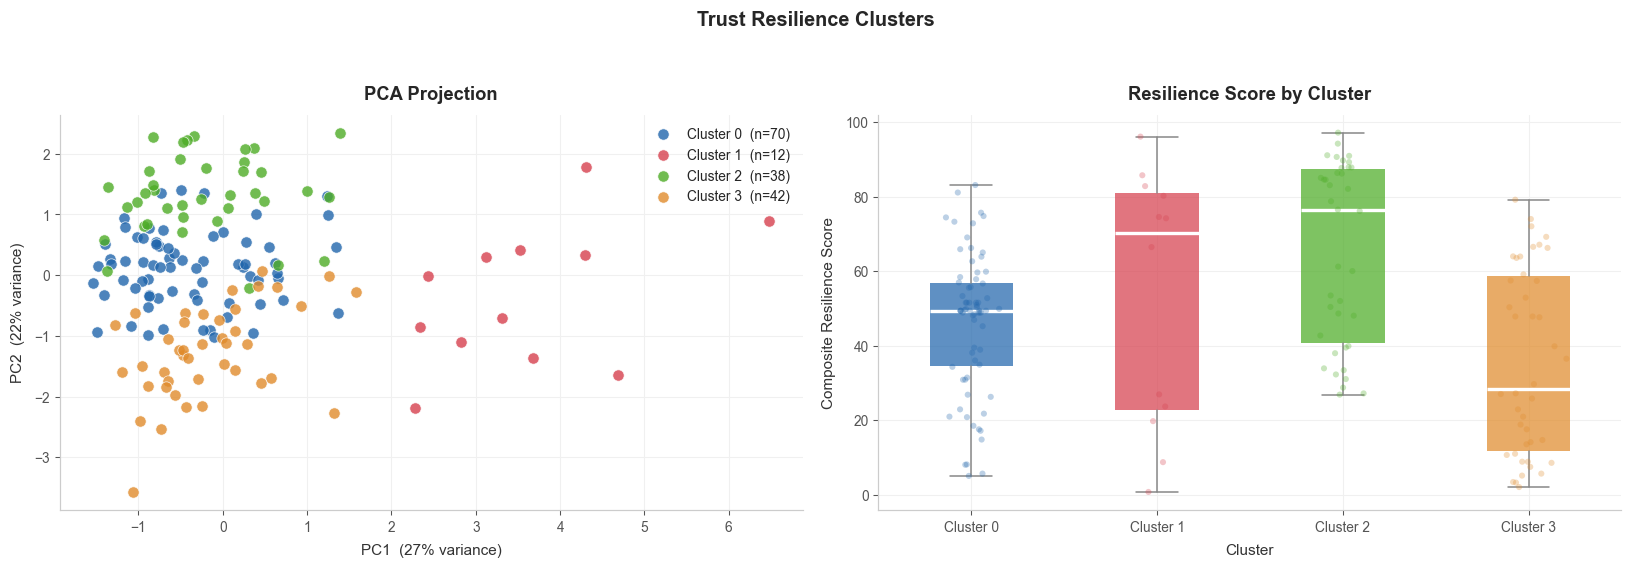

In [40]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_clust["pca1"] = coords[:, 0]
df_clust["pca2"] = coords[:, 1]

cluster_ids = sorted(df_clust["cluster"].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Trust Resilience Clusters", fontsize=13, fontweight="bold", y=1.03)

# ── PCA scatter ──
ax = axes[0]
for c in cluster_ids:
    sub = df_clust[df_clust["cluster"] == c]
    ax.scatter(
        sub["pca1"], sub["pca2"],
        label=f"Cluster {c}  (n={len(sub)})",
        color=CLUSTER_COLORS[c], alpha=0.8,
        edgecolors="white", linewidth=0.5, s=55,
    )
ax.set_title("PCA Projection")
ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.legend(fontsize=9)

# ── Boxplot with individual point jitter ──
ax = axes[1]
cluster_data = [df_clust[df_clust["cluster"] == c]["resilience_score"].values
                for c in cluster_ids]

bp = ax.boxplot(
    cluster_data, patch_artist=True,
    medianprops=dict(color="white", linewidth=2.2),
    whiskerprops=dict(linewidth=1.0, color="#888888"),
    capprops=dict(linewidth=1.0, color="#888888"),
    flierprops=dict(marker="o", markersize=3, alpha=0.35, markeredgewidth=0),
    boxprops=dict(linewidth=0),
)
for patch, c in zip(bp["boxes"], cluster_ids):
    patch.set_facecolor(CLUSTER_COLORS[c])
    patch.set_alpha(0.72)

# jittered individual points overlaid
rng = np.random.default_rng(42)
for i, c in enumerate(cluster_ids):
    y = df_clust[df_clust["cluster"] == c]["resilience_score"].values
    x = rng.normal(i + 1, 0.07, size=len(y))
    ax.scatter(x, y, color=CLUSTER_COLORS[c], alpha=0.30,
               s=16, edgecolors="none", zorder=3)

ax.set_title("Resilience Score by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Composite Resilience Score")
ax.set_xticklabels([f"Cluster {c}" for c in cluster_ids])

fig.tight_layout()
plt.show()